In [6]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns",None)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [9]:
## Load Dataset
df = pd.read_excel("Week 2 (DataSet).xlsx")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [10]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
df.shape

(35040, 11)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), o

In [6]:
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


In [12]:
df.isnull().sum()

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

In [8]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='str')

In [13]:
# Data Cleaning and Feature Engineering
df["date"]=pd.to_datetime(df["date"])

In [14]:
df["Hour"]=df["date"].dt.hour

In [15]:
df[["date","Hour"]].head()

,date,Hour
0,2018-01-01 00:15:00,0
1,2018-01-01 00:30:00,0
2,2018-01-01 00:45:00,0
3,2018-01-01 01:00:00,1
4,2018-01-01 01:15:00,1


In [16]:
df["Day_Name"]=df["date"].dt.day_name()

In [17]:
df[["date","Day_Name"]].head()

,date,Day_Name
0,2018-01-01 00:15:00,Monday
1,2018-01-01 00:30:00,Monday
2,2018-01-01 00:45:00,Monday
3,2018-01-01 01:00:00,Monday
4,2018-01-01 01:15:00,Monday


In [14]:
df["Month"]=df["date"].dt.month_name()

In [19]:
df["Weekend"]=np.where(df["date"].dt.dayofweek>=5,1,0)

In [20]:
df[["date","Weekend"]].head()

,date,Weekend
0,2018-01-01 00:15:00,0
1,2018-01-01 00:30:00,0
2,2018-01-01 00:45:00,0
3,2018-01-01 01:00:00,0
4,2018-01-01 01:15:00,0


In [21]:
# Feature Engineering
# Create Power Factor Ratio Feature

df["Power_Factor_Ratio"] = np.where(
    (df["Leading_Current_Power_Factor"] == 0) &
    (df["Lagging_Current_Power_Factor"] == 0),
    1.0,
    df["Leading_Current_Power_Factor"] / df["Lagging_Current_Power_Factor"]
)

df[[
    "Leading_Current_Power_Factor",
    "Lagging_Current_Power_Factor",
    "Power_Factor_Ratio"
]].head()

,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117


In [24]:
# High Load Feature
# Calculate 75th percentile

threshold = df["Usage_kWh"].quantile(0.75)

print("75th Percentile:", threshold)

75th Percentile: 51.2375


In [25]:
# Create High_Load Feature

df["High_Load"] = np.where(
    df["Usage_kWh"] > threshold,
    1,
    0
)

df[["Usage_kWh", "High_Load"]].head(10)

,Usage_kWh,High_Load
0,3.17,0
1,4.00,0
2,3.24,0
3,3.31,0
4,3.82,0
5,3.28,0
6,3.60,0
7,3.60,0
8,3.28,0
9,3.78,0


In [26]:
# Outlier Detection using IQR Method
Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Usage_kWh"] < lower_bound) |
    (df["Usage_kWh"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Total Outliers:", len(outliers))

Lower Bound: -68.85624999999999
Upper Bound: 123.29374999999999
Total Outliers: 328


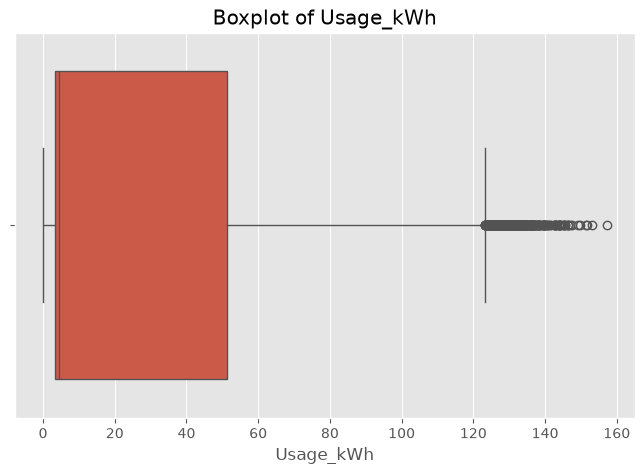

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Usage_kWh"])

plt.title("Boxplot of Usage_kWh")

plt.xlabel("Usage_kWh")

plt.show()

In [ ]:
## Observation Using the IQR method, a total of **328 outliers** were detected 
##in the **Usage_kWh** feature. These observations represent unusually high energy consumption values.
##Since this is a real industrial dataset, these outliers may correspond to actual periods of high production 
##rather than data entry errors. Therefore, they were identified but not removed during the exploratory analysis.

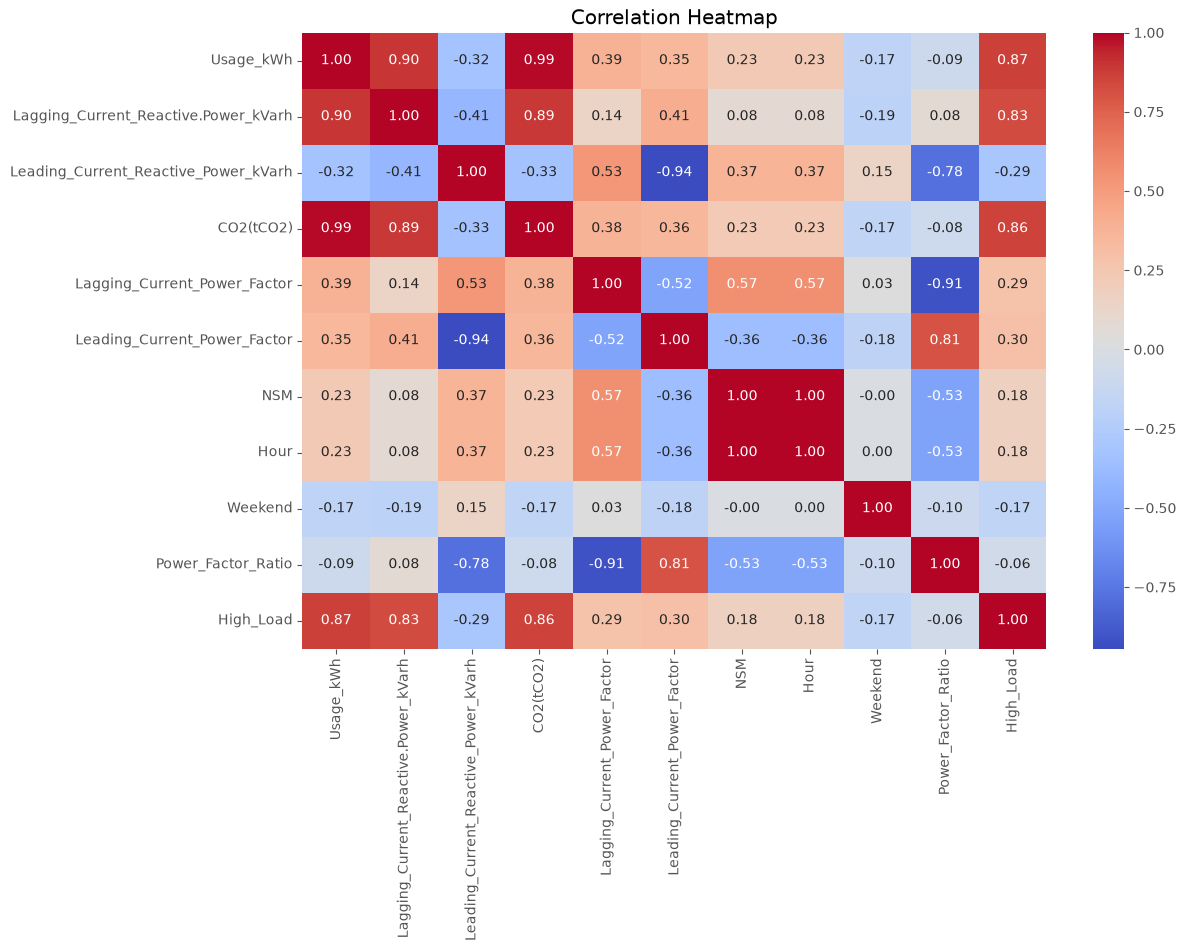

In [27]:
# Correlation Analysis
# Correlation Matrix

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
# Top Correlated Features with Usage_kWh

features = [
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM",
    "Hour",
    "Power_Factor_Ratio"
]

corr = df[features + ["Usage_kWh"]].corr()

corr_usage = corr["Usage_kWh"].sort_values(ascending=False)

print(corr_usage)

Usage_kWh                               1.000000
CO2(tCO2)                               0.988180
Lagging_Current_Reactive.Power_kVarh    0.896150
Lagging_Current_Power_Factor            0.385960
Leading_Current_Power_Factor            0.353566
NSM                                     0.234610
Hour                                    0.234175
Power_Factor_Ratio                     -0.090086
Leading_Current_Reactive_Power_kVarh   -0.324922
Name: Usage_kWh, dtype: float64


In [30]:
# Average Energy Consumption by Load Type
# Calculate average energy consumption for each load type

avg_load = df.groupby("Load_Type")["Usage_kWh"].mean().reset_index()

avg_load

,Load_Type,Usage_kWh
0,Light_Load,8.626207
1,Maximum_Load,59.265314
2,Medium_Load,38.445394


C:\Users\Momina\AppData\Local\Temp\ipykernel_22284\2691931995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


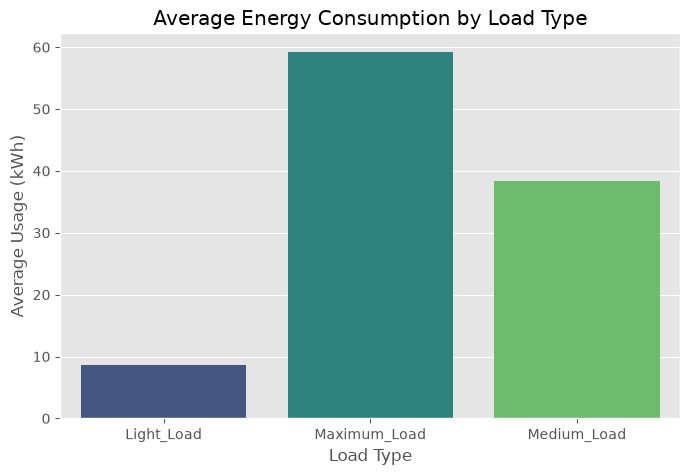

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_load,
    x="Load_Type",
    y="Usage_kWh",
    palette="viridis"
)

plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")

plt.show()

In [ ]:
### Observation The **Maximum Load** category shows the highest average energy consumption,
##followed by **Medium Load**, while **Light Load** has the lowest average usage. 
##This indicates that production load has a significant impact on electricity consumption.

In [26]:
# Average Energy Consumption by Hour
hourly_usage = df.groupby("Hour")["Usage_kWh"].mean().reset_index()

hourly_usage.head()

,Hour,Usage_kWh
0,0,7.870075
1,1,6.072479
2,2,4.428390
3,3,4.358041
4,4,4.309438


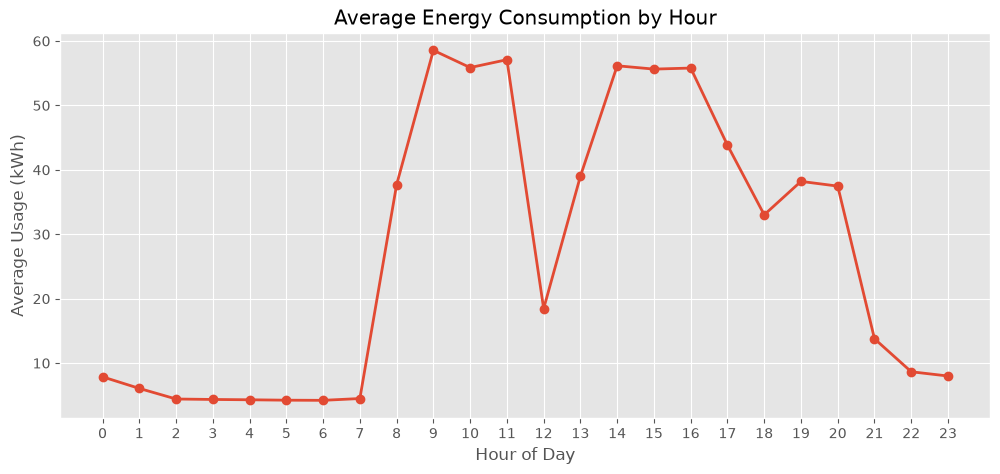

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    hourly_usage["Hour"],
    hourly_usage["Usage_kWh"],
    marker="o",
    linewidth=2
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Usage (kWh)")

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

In [ ]:
### Observation , The hourly trend shows that energy consumption changes throughout the day. 
## Higher consumption during specific hours may correspond to peak production activities, 
## while lower usage likely represents reduced industrial operations.

In [28]:
df.to_csv("steel_engineered.csv", index=False)
print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!


In [ ]:
## EDA Summary

This exploratory data analysis was performed on the Steel Industry Energy Consumption dataset:
 -to understand energy usage behavior
 -detect data quality issues, 
 -and identify key driving factors behind electricity consumption in an industrial environment.

##The dataset showed the presence of 328 outliers in the Usage_kWh feature, detected using the IQR method.
##These values represent unusually high energy consumption levels, which are likely associated with peak production cycles rather than data errors.
##Since this is a real-world industrial dataset, these outliers were retained to preserve meaningful operational variations.


##Correlation analysis revealed that *CO2(tCO2)* showed the strongest positive correlation with 
     ## Usage_kWh(0.988), followed by *Lagging Current Reactive Power (kVarh)* (0.896) and **Lagging Current Power Factor** (0.386). 
     -These variables appear to have the greatest influence on energy consumption.
         
##Feature-wise analysis highlighted clear operational patterns.
##Energy consumption varies significantly across load types, with Maximum Load conditions showing:
     -the highest average usage, followed by Medium and Light Load conditions. 
     This confirms that production intensity is a major driver of electricity demand.
         
##Additionally, hourly trend analysis revealed:
         fluctuating energy usage throughout the day,  with noticeable peaks during active production hours
         and reduced consumption during off-peak periods.

##Overall, the analysis suggests that:
     "energy consumption in the steel plant is strongly influenced by operational load levels and time-based production schedules". 
     
##A key hypothesis is that: 
     -energy spikes occur during high-demand manufacturing periods when multiple heavy machines operate simultaneously,
      leading to increased load and reactive power requirements.